In [10]:
import zipfile
import os

zip_path = '/content/FruitinAmazon.zip'
extract_path = '/content/FruitinAmazon'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted successfully!")

Extracted successfully!


In [11]:
train_dir = '/content/FruitinAmazon/FruitinAmazon/train'
test_dir  = '/content/FruitinAmazon/FruitinAmazon/test'

print("Train dir exists:", os.path.exists(train_dir))
print("Test dir exists: ", os.path.exists(test_dir))

Train dir exists: True
Test dir exists:  True


Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


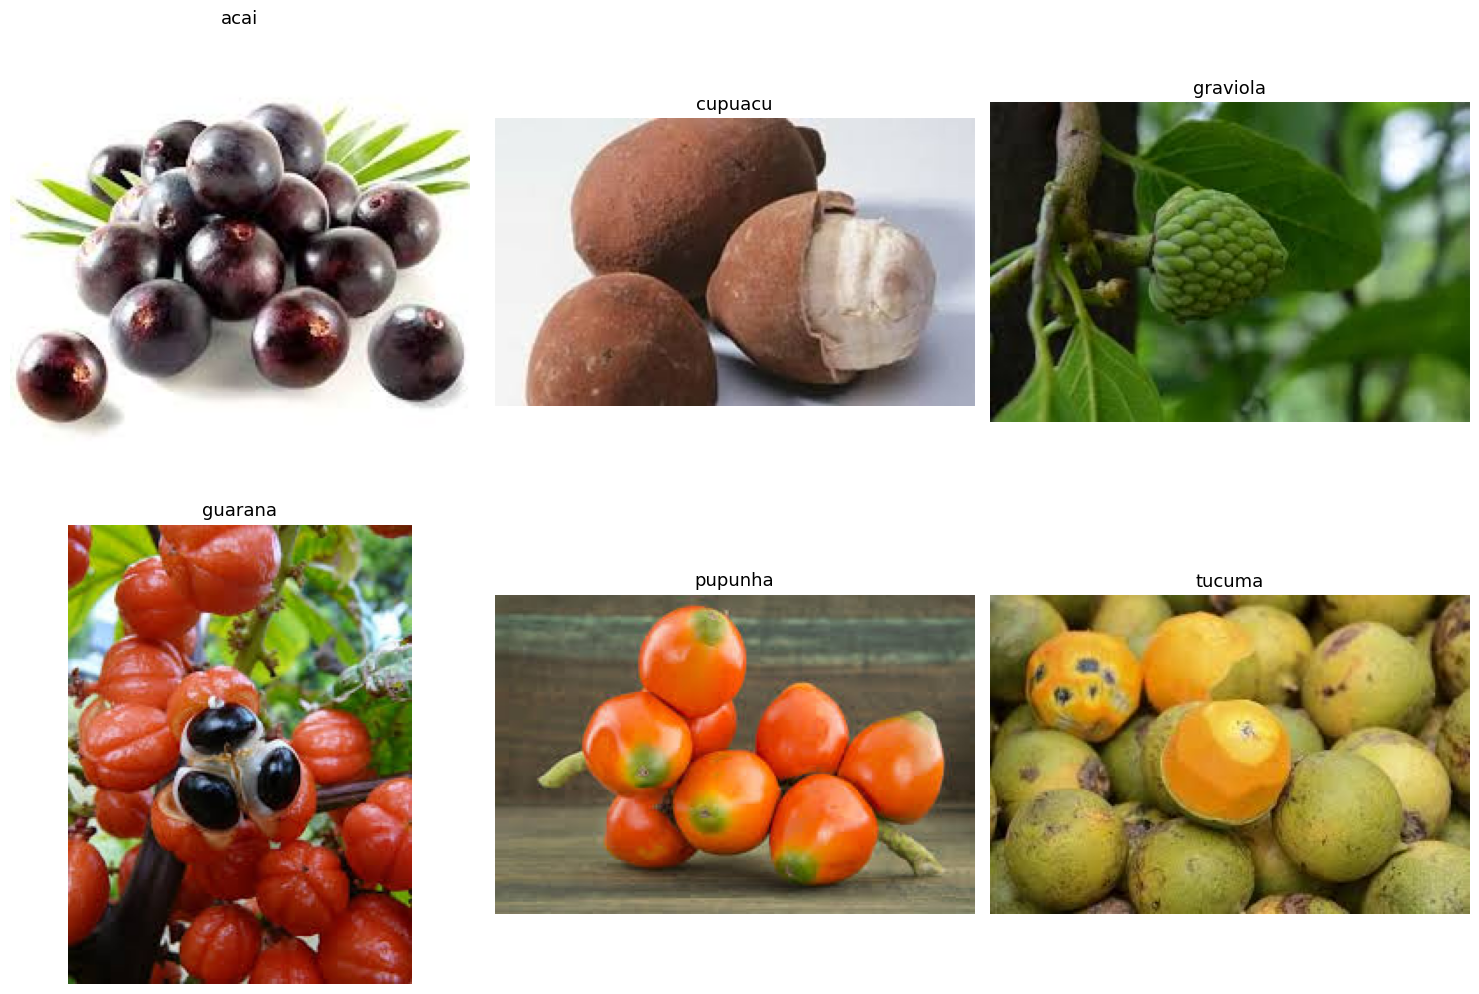

In [29]:
#Task 1)a: Visualizing One Image Per Class (2-row grid)
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

# Get all class folder names
class_dirs = sorted([d for d in os.listdir(train_dir)
                     if os.path.isdir(os.path.join(train_dir, d))])
print("Classes found:", class_dirs)

num_classes = len(class_dirs)
cols = 3
rows = 2  # exactly 2 rows as required by worksheet

fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
axes = axes.flatten()

for i, cls in enumerate(class_dirs):
    cls_path = os.path.join(train_dir, cls)
    images = [f for f in os.listdir(cls_path)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    img_path = os.path.join(cls_path, random.choice(images))
    img = mpimg.imread(img_path)
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=13)
    axes[i].axis('off')

# Hide unused subplots if any
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [30]:
#Task 1)b: Checking & Remove Corrupted Images
from PIL import Image

corrupted = []

for cls in class_dirs:
    cls_path = os.path.join(train_dir, cls)
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()
        except (IOError, SyntaxError):
            print(f"Removed corrupted image: {img_path}")
            os.remove(img_path)
            corrupted.append(img_path)

if not corrupted:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


In [31]:
#Task 2)a: Loading & Preprocess Training and Validation Data
import tensorflow as tf

img_height       = 128
img_width        = 128
batch_size       = 32
validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1./255)

# --- Training dataset ---
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# --- Validation dataset ---
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Save class_names BEFORE applying map()
class_names = train_ds.class_names
num_classes  = len(class_names)
print("Classes:", class_names)
print("Number of classes:", num_classes)

# Apply normalization AFTER saving class_names
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds   = val_ds.map(lambda x, y: (rescale(x), y))

print("Train and Validation datasets ready!")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6
Train and Validation datasets ready!


In [32]:
#Task 2)b: Loading & Preprocess Test Data
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    seed=123
)

test_ds = test_ds.map(lambda x, y: (rescale(x), y))
print("Test dataset ready!")


Found 30 files belonging to 6 classes.
Test dataset ready!


In [18]:
#Task 3: Building the CNN Model
from tensorflow.keras import layers, models

model = models.Sequential([

    # --- Convolutional Block 1 ---
    layers.Conv2D(filters=32, kernel_size=(3,3), padding='same',
                  strides=1, activation='relu',
                  input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D(pool_size=(2,2), strides=2),

    # --- Convolutional Block 2 ---
    layers.Conv2D(filters=32, kernel_size=(3,3), padding='same',
                  strides=1, activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2), strides=2),

    # --- Fully Connected Layers ---
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64,  activation='relu'),

    # --- Output Layer ---
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
#Task 4: Compiling the Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")


Model compiled successfully!


In [20]:
#Training the Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Save best model automatically
checkpoint = ModelCheckpoint(
    filepath='best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Stop early if model stops improving
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    epochs=250,
    validation_data=val_ds,
    callbacks=[checkpoint, early_stop]
)

print("Training complete!")

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 950ms/step - accuracy: 0.1094 - loss: 2.4404
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.1250 - loss: 2.7665 - val_accuracy: 0.0000e+00 - val_loss: 2.6249
Epoch 2/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.1562 - loss: 2.4441
Epoch 2: val_accuracy improved from 0.00000 to 0.05556, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.3194 - loss: 2.1635 - val_accuracy: 0.0556 - val_loss: 1.5454
Epoch 3/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.3438 - loss: 1.6355
Epoch 3: val_accuracy improved from 0.05556 to 0.16667, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.4444 - loss: 1.6074 - val_accuracy: 0.1667 - val_loss: 1.5283
Epoch 4/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5000 - loss: 1.4431
Epoch 4: val_accuracy did not improve from 0.16667
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4444 - loss: 1.4472 - val_accuracy: 0.1111 - val_loss: 1.6101
Epoch 5/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5000 - loss: 1.3126
Epoch 5: val_accuracy improved from 0.16667 to 0.61111, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.5000 - loss: 1.2834 - val_accuracy: 0.6111 - val_loss: 1.0659
Epoch 6/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5625 - loss: 1.1291
Epoch 6: val_accuracy improved from 0.61111 to 0.83333, saving model to best_model.h5



Epoch 6: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.5833 - loss: 1.0856 - val_accuracy: 0.8333 - val_loss: 0.7994
Epoch 7/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7812 - loss: 0.6991
Epoch 7: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7778 - loss: 0.7821 - val_accuracy: 0.6667 - val_loss: 0.9651
Epoch 8/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8750 - loss: 0.6259
Epoch 8: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8750 - loss: 0.6210 - val_accuracy: 0.7222 - val_loss: 0.6349
Epoch 9/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9375 - loss: 0.4098
Epoch 9: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8472 - loss: 0.5317 - val_accuracy: 0.8333 - val_loss: 0.5551
Epoch 10/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9688 - loss: 0.2958
Epoc

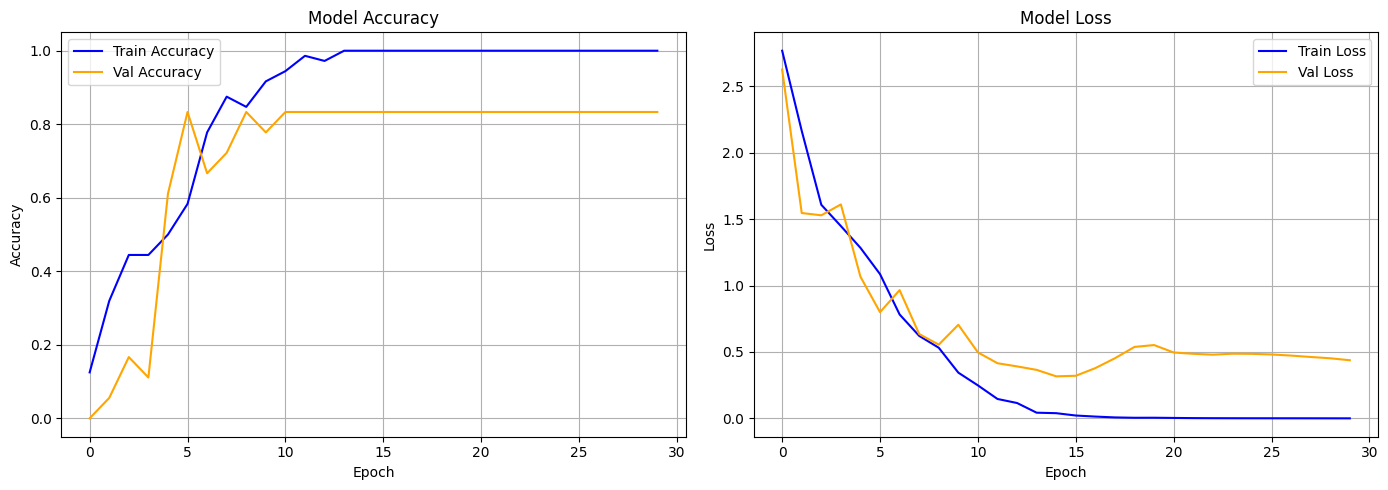

In [21]:
#Visualize Training & Validation Accuracy and Loss
plt.figure(figsize=(14, 5))

# --- Accuracy Plot ---
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# --- Loss Plot ---
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss',   color='orange')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [22]:
#Task 5: Evaluating the Model on Test Set
test_loss, test_acc = model.evaluate(test_ds)

print(f"\nTest Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 833ms/step - accuracy: 0.7333 - loss: 0.5888

Test Loss:     0.5888
Test Accuracy: 0.7333


In [24]:
#Task 6: Saving the Model
model.save('fruit_cnn_model.h5')
print("Model saved as fruit_cnn_model.h5")

Model saved as fruit_cnn_model.h5


In [27]:
#Task 6: Loading the Model & Re-evaluate
loaded_model = tf.keras.models.load_model('fruit_cnn_model.h5')
print("Model loaded successfully! ")

loss, acc = loaded_model.evaluate(test_ds)
print(f"\nLoaded Model — Test Loss: {loss:.4f} | Test Accuracy: {acc:.4f}")


Model loaded successfully! 
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 670ms/step - accuracy: 0.7333 - loss: 0.5888

Loaded Model — Test Loss: 0.5888 | Test Accuracy: 0.7333


In [28]:
#Task 7: Predictions + Classification Report
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print("\n===== Classification Report =====\n")
print(classification_report(y_true, y_pred, target_names=class_names))


===== Classification Report =====

              precision    recall  f1-score   support

        acai       0.75      0.60      0.67         5
     cupuacu       0.44      0.80      0.57         5
    graviola       0.80      0.80      0.80         5
     guarana       1.00      0.80      0.89         5
     pupunha       0.83      1.00      0.91         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.73        30
   macro avg       0.80      0.73      0.73        30
weighted avg       0.80      0.73      0.73        30



In [33]:
from google.colab import files
files.download('fruit_cnn_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>